In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

## 1. Load the test split and predictions

In [2]:
BASELINE_DIR = "../RAGTruth/baseline"
PREDICTIONS_FILE = "gpt_baseline_predictions.jsonl"

def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records

test_all = load_jsonl(os.path.join(BASELINE_DIR, "test.jsonl"))
predictions = load_jsonl(PREDICTIONS_FILE)

print(f"Full test split size : {len(test_all)}")
print(f"Predictions loaded   : {len(predictions)}")
print()
print("Task distribution in predictions:")
print(pd.Series([r["task_type"] for r in predictions]).value_counts().to_string())

Full test split size : 2675
Predictions loaded   : 99

Task distribution in predictions:
QA          33
Summary     33
Data2txt    33


## 3. Case-level metrics

In [3]:
def compute_case_metrics(records):
    y_true = [1 if len(r["labels"]) > 0 else 0 for r in records]
    y_pred = [1 if len(r.get("pred", [])) > 0 else 0 for r in records]
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    return y_true, y_pred, round(p, 4), round(r, 4), round(f, 4)

rows = []
all_true, all_pred = [], []
for task in ["QA", "Summary", "Data2txt"]:
    subset = [r for r in predictions if r["task_type"] == task]
    y_true, y_pred, p, r, f = compute_case_metrics(subset)
    all_true.extend(y_true)
    all_pred.extend(y_pred)
    rows.append({"Task": task, "n": len(subset), "Precision": p, "Recall": r, "F1": f})

p_ov, r_ov, f_ov = (
    round(precision_score(all_true, all_pred, zero_division=0), 4),
    round(recall_score(all_true, all_pred, zero_division=0), 4),
    round(f1_score(all_true, all_pred, zero_division=0), 4),
)
rows.append({"Task": "Overall", "n": len(predictions), "Precision": p_ov, "Recall": r_ov, "F1": f_ov})

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))

    Task  n  Precision  Recall     F1
      QA 33     0.5714  1.0000 0.7273
 Summary 33     0.5000  0.4000 0.4444
Data2txt 33     0.8696  0.9091 0.8889
 Overall 99     0.7368  0.7778 0.7568


## 4. Bar chart: Precision / Recall / F1 by task

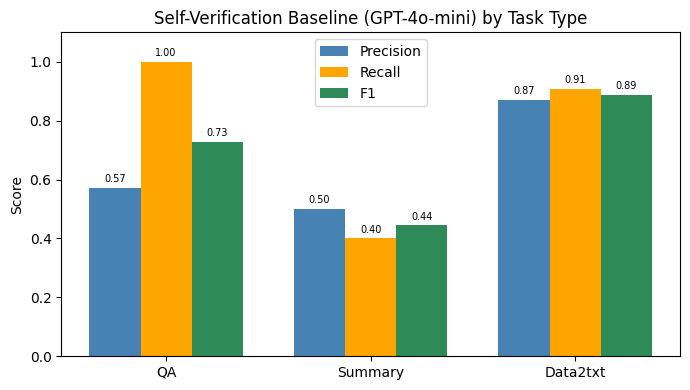

In [4]:
task_df = df_metrics[df_metrics["Task"] != "Overall"].reset_index(drop=True)

x = np.arange(len(task_df))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width, task_df["Precision"], width=width, label="Precision", color="steelblue")
ax.bar(x,          task_df["Recall"],   width=width, label="Recall",    color="orange")
ax.bar(x + width,  task_df["F1"],       width=width, label="F1",        color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(task_df["Task"].tolist())
ax.set_ylim(0, 1.1)
ax.set_title("Self-Verification Baseline (GPT-4o-mini) by Task Type")
ax.set_ylabel("Score")
ax.legend()
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}", ha="center", fontsize=7)
plt.tight_layout()
plt.show()

## 5. Confusion matrix

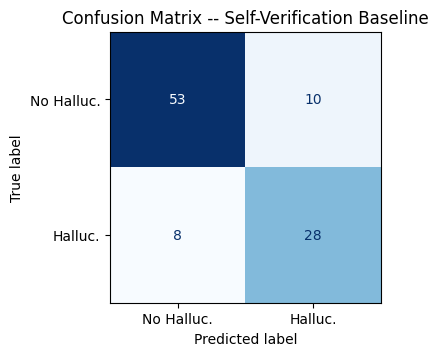

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Halluc.", "Halluc."])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix -- Self-Verification Baseline")
plt.tight_layout()
plt.show()

## 6. Hallucination rate in predictions vs gold

           gold   pred
task                  
Data2txt  0.667  0.697
QA        0.121  0.212
Summary   0.303  0.242


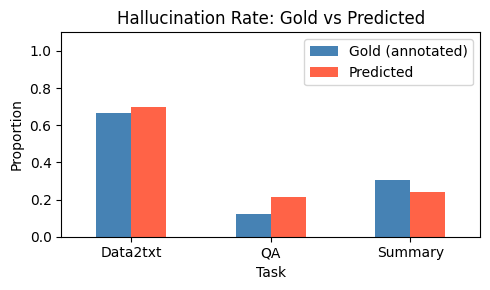

In [7]:
gold_halu   = [1 if len(r["labels"]) > 0 else 0 for r in predictions]
pred_halu   = [1 if len(r.get("pred", [])) > 0 else 0 for r in predictions]
task_labels = [r["task_type"] for r in predictions]

df_comp = pd.DataFrame({"task": task_labels, "gold": gold_halu, "pred": pred_halu})
summary = df_comp.groupby("task")[["gold", "pred"]].mean().round(3)
print(summary)

fig, ax = plt.subplots(figsize=(5, 3))
summary.plot(kind="bar", ax=ax, color=["steelblue", "tomato"])
ax.set_title("Hallucination Rate: Gold vs Predicted")
ax.set_ylabel("Proportion")
ax.set_xlabel("Task")
ax.set_ylim(0, 1.1)
ax.legend(["Gold (annotated)", "Predicted"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Classification report

In [8]:
print(classification_report(all_true, all_pred, target_names=["No Hallucination", "Hallucination"], zero_division=0))

                  precision    recall  f1-score   support

No Hallucination       0.87      0.84      0.85        63
   Hallucination       0.74      0.78      0.76        36

        accuracy                           0.82        99
       macro avg       0.80      0.81      0.81        99
    weighted avg       0.82      0.82      0.82        99



## 9. Sample predictions

In [9]:
correct = [r for r in predictions if (len(r["labels"]) > 0) == (len(r.get("pred", [])) > 0)]
wrong   = [r for r in predictions if (len(r["labels"]) > 0) != (len(r.get("pred", [])) > 0)]

print(f"Correct: {len(correct)} / {len(predictions)}  |  Wrong: {len(wrong)} / {len(predictions)}")
print()

for label, group in [("Correct", correct[:3]), ("Incorrect", wrong[:3])]:
    print(f"=== {label} ===")
    for rec in group:
        gold_spans = [l["text"] for l in rec["labels"]]
        pred_spans = rec.get("pred", [])
        print(f"  Task  : {rec['task_type']}  |  Model: {rec['model']}")
        print(f"  Gold  : {gold_spans[:3]}")
        print(f"  Pred  : {pred_spans[:3]}")
        print()

Correct: 81 / 99  |  Wrong: 18 / 99

=== Correct ===
  Task  : QA  |  Model: gpt-4-0613
  Gold  : []
  Pred  : []

  Task  : QA  |  Model: gpt-3.5-turbo-0613
  Gold  : []
  Pred  : []

  Task  : QA  |  Model: llama-2-13b-chat
  Gold  : ['the lowest average pay in Mississippi ($18.60 per hour or $38,900 per year)']
  Pred  : ['the passages do not provide specific information on how automotive technicians get paid or their typical salaries', 'I am unable to answer the question based on the given passages']

=== Incorrect ===
  Task  : QA  |  Model: llama-2-7b-chat
  Gold  : []
  Pred  : ['the passage does not provide specific information on the average hourly rate or salary range for automotive technicians', 'the passage does not provide specific data on the average hourly rate or salary range for automotive technicians', 'it is unable to answer the question with confidence']

  Task  : QA  |  Model: llama-2-7b-chat
  Gold  : []
  Pred  : ['tartate']

  Task  : QA  |  Model: llama-2-7b-c